# B4 — Seasonal Models

**Reference:** W&H: The Multiple Regression DLM; Petris: State Space Models

**Concepts introduced:**
- Seasonal component in dummy form (sum-to-zero constraint)
- Combining specs with `combine()` (block-diagonal system matrices)
- Decomposing an observed series into trend + seasonal components
- Effect of `W_season` on seasonal rigidity

In [1]:
import sys
from pathlib import Path
project_root = Path().resolve().parents[1]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import matplotlib.pyplot as plt
from engine.models import make_local_linear_trend, make_seasonal_factor, combine
from engine.filter import kalman_filter
from engine.smoother import rts_smoother
from engine.simulate import simulate

## 1. The problem: ignored seasonality

When a series has a periodic pattern and we fit a trend-only model, the residuals
show strong autocorrelation at the seasonal lag.

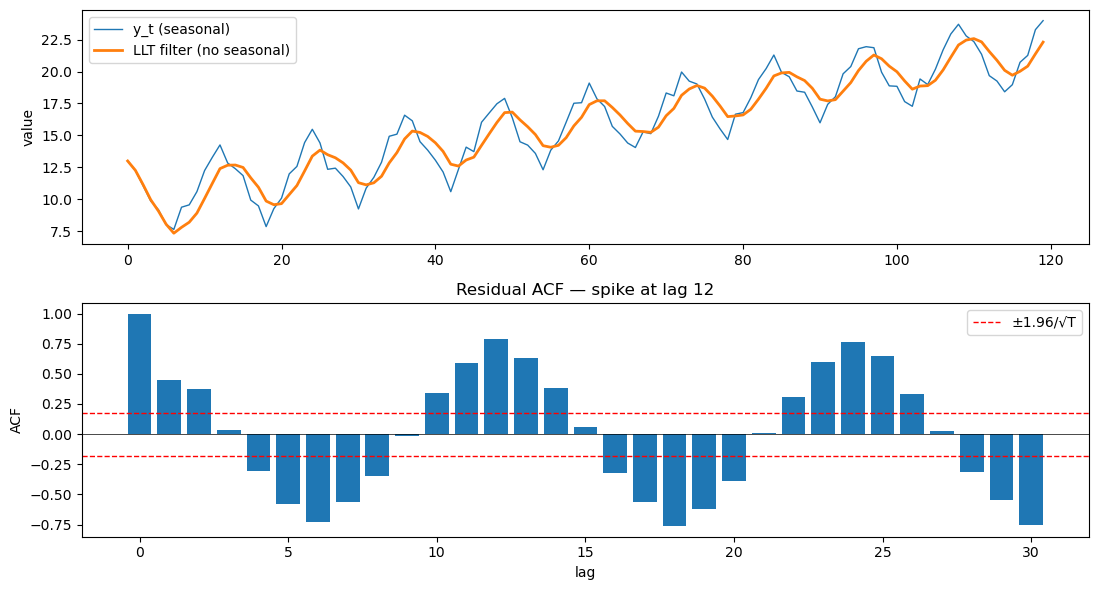

In [2]:
# Simulate a series with monthly seasonality but fit trend-only
rng = np.random.default_rng(7)
T, s = 120, 12

# Build true seasonal pattern (sum-to-zero)
seasonal_pattern = np.array([3, 2, 1, 0, -1, -2, -3, -2, -1, 0, 1, 2], dtype=float)
seasonal_pattern -= seasonal_pattern.mean()   # enforce mean zero

t_arr = np.arange(T)
true_level = 10.0 + 0.1 * t_arr
true_seasonal = np.tile(seasonal_pattern, T // s)
y_seasonal = true_level + true_seasonal + rng.normal(0, 0.5, T)

# Fit a trend-only LLT — ignores seasonality
spec_ll = make_local_linear_trend(V=1.0, W_level=0.1, W_slope=0.001)
fr_ll   = kalman_filter(spec_ll, y_seasonal[:, None])
residuals = y_seasonal - fr_ll.f[:, 0]

fig, axes = plt.subplots(2, 1, figsize=(11, 6))
axes[0].plot(t_arr, y_seasonal, lw=1, label="y_t (seasonal)")
axes[0].plot(t_arr, fr_ll.m[:, 0], "C1-", lw=2, label="LLT filter (no seasonal)")
axes[0].set_ylabel("value"); axes[0].legend()

# ACF of residuals
max_lag = 30
acf = [np.corrcoef(residuals[lag:], residuals[:-lag] if lag else residuals)[0, 1]
       for lag in range(max_lag + 1)]
axes[1].bar(range(max_lag + 1), acf, color="C0")
axes[1].axhline(0, color="k", lw=0.5)
axes[1].axhline( 1.96/np.sqrt(T), color="r", ls="--", lw=1, label="\u00b11.96/\u221aT")
axes[1].axhline(-1.96/np.sqrt(T), color="r", ls="--", lw=1)
axes[1].set(xlabel="lag", ylabel="ACF", title="Residual ACF \u2014 spike at lag 12")
axes[1].legend()
plt.tight_layout()
plt.show()

## 2. Dummy seasonal representation

For a period-$s$ seasonal pattern, we use the **dummy seasonal** form (W&H: The Multiple Regression DLM).
The state has dimension $s-1$ and encodes the last $s-1$ seasonal effects.
The current seasonal factor is their negated sum — enforcing the sum-to-zero constraint.

**Evolution matrix** (companion/rotation form):

$$J_s = \begin{pmatrix}
-1 & -1 & \cdots & -1 & -1 \\
 1 &  0 & \cdots &  0 &  0 \\
 0 &  1 & \cdots &  0 &  0 \\
\vdots & & \ddots & & \vdots \\
 0 &  0 & \cdots &  1 &  0
\end{pmatrix}$$

Only $W_\text{season}$ on the top-left of $W$ drives seasonal innovation;
the remaining entries are near-zero (numerical nugget).

**`make_seasonal_factor(period, V, W_season)`** builds this spec.
Use **`combine(spec1, spec2)`** to merge it with an LLT spec (block-diagonal $G$ and $W$,
combined $F$, $V$ from the first spec).

**Important:** `combine()` requires both specs to share the same `V` value.

In [3]:
# Build LLT + seasonal combined model
# Both specs must have the same V
llt_spec  = make_local_linear_trend(V=0.25, W_level=0.05, W_slope=0.001)
seas_spec = make_seasonal_factor(period=12, V=0.25, W_season=0.01)
spec      = combine(llt_spec, seas_spec)

print(f"State dim d: {spec.G.shape[0]}  (2 LLT + 11 seasonal = 13)")
print(f"F shape: {spec.F.shape}")
print(f"G shape: {spec.G.shape}")

State dim d: 13  (2 LLT + 11 seasonal = 13)
F shape: (1, 13)
G shape: (13, 13)


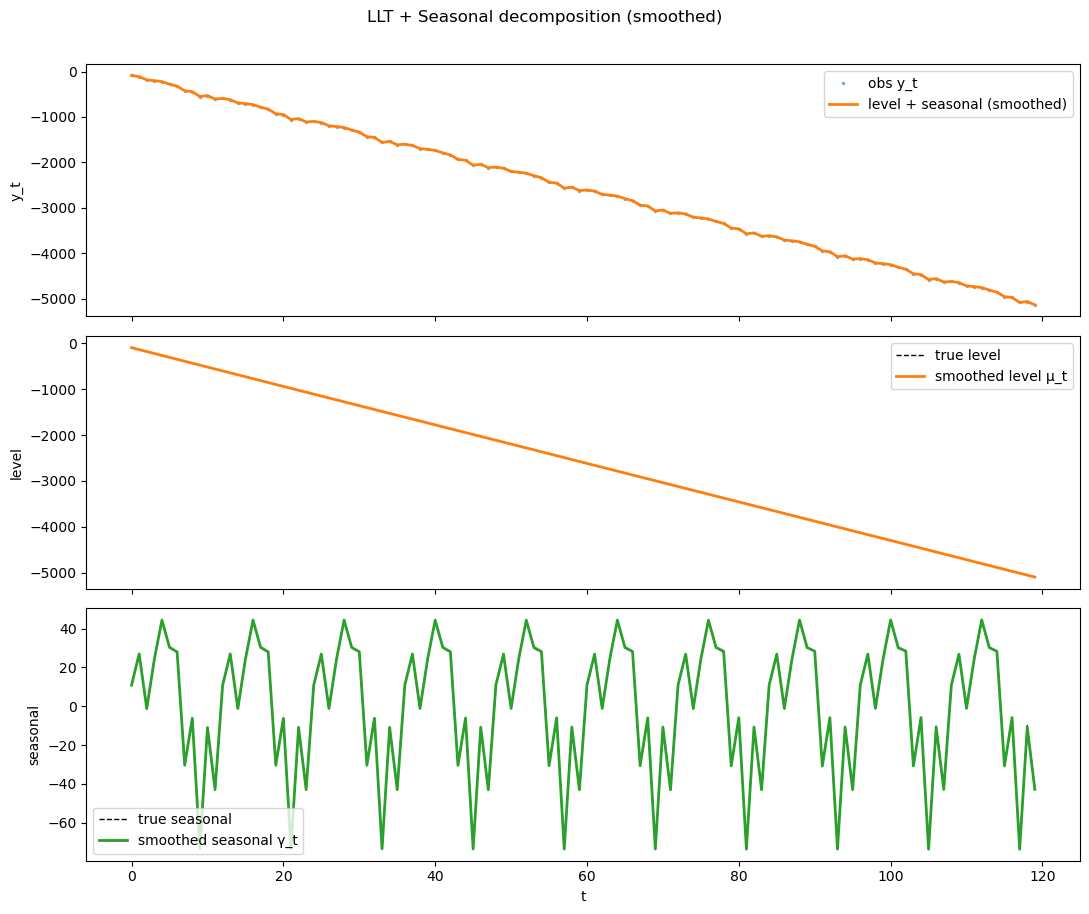

Log marginal likelihood: -202.66


In [4]:
sim  = simulate(spec, n=T, seed=8)
fr   = kalman_filter(spec, sim.y)
sr   = rts_smoother(spec, fr)

# State layout from combine(): [level(0), slope(1), seasonal_0(2), ..., seasonal_10(12)]
smooth_level    = sr.s[:, 0]   # level \u03bc_t
smooth_slope    = sr.s[:, 1]   # slope \u03b2_t
smooth_seasonal = sr.s[:, 2]   # leading seasonal factor \u03b3_t

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
axes[0].plot(t_arr, sim.y[:, 0], ".", ms=3, alpha=0.5, label="obs y_t")
axes[0].plot(t_arr, smooth_level + smooth_seasonal, "C1-", lw=2,
             label="level + seasonal (smoothed)")
axes[0].set_ylabel("y_t"); axes[0].legend()

axes[1].plot(t_arr, sim.theta_true[:, 0], "k--", lw=1, label="true level")
axes[1].plot(t_arr, smooth_level, "C1-", lw=2, label="smoothed level \u03bc_t")
axes[1].set_ylabel("level"); axes[1].legend()

axes[2].plot(t_arr, sim.theta_true[:, 2], "k--", lw=1, label="true seasonal")
axes[2].plot(t_arr, smooth_seasonal, "C2-", lw=2, label="smoothed seasonal \u03b3_t")
axes[2].set_xlabel("t"); axes[2].set_ylabel("seasonal"); axes[2].legend()

plt.suptitle("LLT + Seasonal decomposition (smoothed)", y=1.01)
plt.tight_layout()
plt.show()
print(f"Log marginal likelihood: {fr.loglik:.2f}")

## 3. Effect of W_season

Large `W_season`: seasonal effects are allowed to drift substantially over time —
the pattern can change shape from year to year.

Small `W_season` (near zero): seasonal effects are nearly fixed — the pattern
repeats almost identically every cycle.

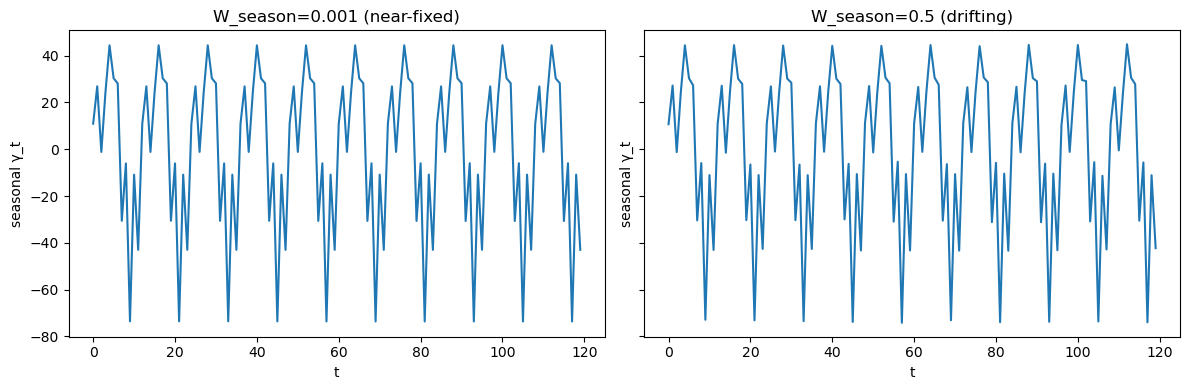

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, W_s, title in zip(
    axes,
    [0.001, 0.5],
    ["W_season=0.001 (near-fixed)", "W_season=0.5 (drifting)"],
):
    llt_s = make_local_linear_trend(V=0.25, W_level=0.05, W_slope=0.001)
    sea_s = make_seasonal_factor(period=12, V=0.25, W_season=W_s)
    sp    = combine(llt_s, sea_s)
    fr_s  = kalman_filter(sp, sim.y)
    sr_s  = rts_smoother(sp, fr_s)
    ax.plot(t_arr, sr_s.s[:, 2], lw=1.5)
    ax.set_title(title); ax.set_xlabel("t"); ax.set_ylabel("seasonal \u03b3_t")
plt.tight_layout()
plt.show()

## Exercises

**Exercise 1** — Set `W_season=0` (use a very small value like `1e-9` to stay
numerically stable). Verify the seasonal component repeats exactly every 12 steps
by checking `np.allclose(sr.s[0, 2], sr.s[12, 2], atol=1e-3)`.

**Exercise 2** — Fit a monthly (`period=12`) model to a series that was generated
with quarterly seasonality (`period=4`). Compare log-likelihoods to show the
mis-specified model does worse:
```python
# Generate quarterly seasonal series
llt_q  = make_local_linear_trend(V=0.25, W_level=0.05, W_slope=0.001)
seas_q = make_seasonal_factor(period=4, V=0.25, W_season=0.01)
spec_q = combine(llt_q, seas_q)
sim_q  = simulate(spec_q, n=48, seed=99)
# Then fit both period=4 and period=12 and compare fr.loglik
```

t=  0: γ=10.956558  t=12: γ=10.956558  close=True
t= 12: γ=10.956558  t=24: γ=10.956558  close=True
t= 24: γ=10.956558  t=36: γ=10.956558  close=True
t= 36: γ=10.956558  t=48: γ=10.956558  close=True
t= 48: γ=10.956558  t=60: γ=10.956558  close=True
t= 60: γ=10.956558  t=72: γ=10.956558  close=True
t= 72: γ=10.956558  t=84: γ=10.956558  close=True
t= 84: γ=10.956558  t=96: γ=10.956557  close=True

np.allclose(sr.s[0, 2], sr.s[12, 2], atol=1e-3): True
All pairs close: True
Conclusion: W_season≈0 forces seasonal pattern to repeat exactly each period


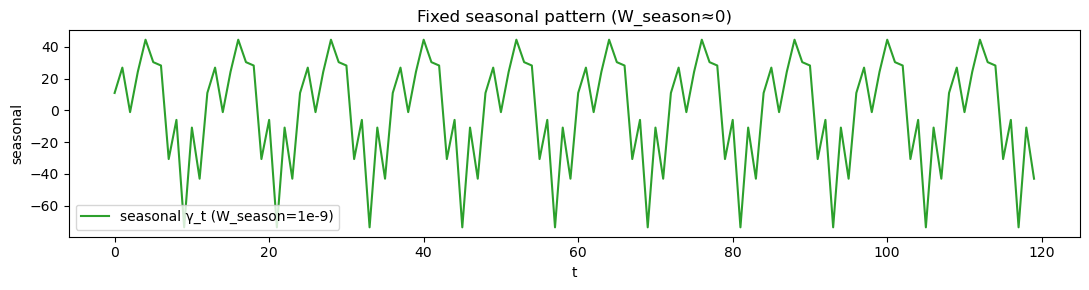

In [6]:
# Exercise 1 — W_season ≈ 0: seasonal repeats exactly every 12 steps
llt_fixed = make_local_linear_trend(V=0.25, W_level=0.05, W_slope=0.001)
seas_fixed = make_seasonal_factor(period=12, V=0.25, W_season=1e-9)
spec_fixed = combine(llt_fixed, seas_fixed)

fr_fixed = kalman_filter(spec_fixed, sim.y)
sr_fixed = rts_smoother(spec_fixed, fr_fixed)

# Check that seasonal factor repeats every 12 steps
seasonal_smooth = sr_fixed.s[:, 2]  # leading seasonal factor

# Compare multiple pairs of points 12 apart
pairs_close = []
for start in range(0, 96, 12):
    val1 = seasonal_smooth[start]
    val2 = seasonal_smooth[start + 12]
    pairs_close.append(np.isclose(val1, val2, atol=1e-3))
    print(f't={start:3d}: γ={val1:.6f}  t={start+12}: γ={val2:.6f}  close={pairs_close[-1]}')

print()
print('np.allclose(sr.s[0, 2], sr.s[12, 2], atol=1e-3):',
      np.allclose(sr_fixed.s[0, 2], sr_fixed.s[12, 2], atol=1e-3))
print('All pairs close:', all(pairs_close))
print('Conclusion: W_season≈0 forces seasonal pattern to repeat exactly each period')

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(t_arr, seasonal_smooth, 'C2-', lw=1.5, label='seasonal γ_t (W_season=1e-9)')
ax.set(xlabel='t', ylabel='seasonal', title='Fixed seasonal pattern (W_season≈0)')
ax.legend()
plt.tight_layout()
plt.show()


Correct model (period=4)  log-lik: -75.12
Mis-specified (period=12) log-lik: -111.63
Advantage of correct model: 36.51 log-units
Correct period=4 model wins — mis-specification hurts the likelihood


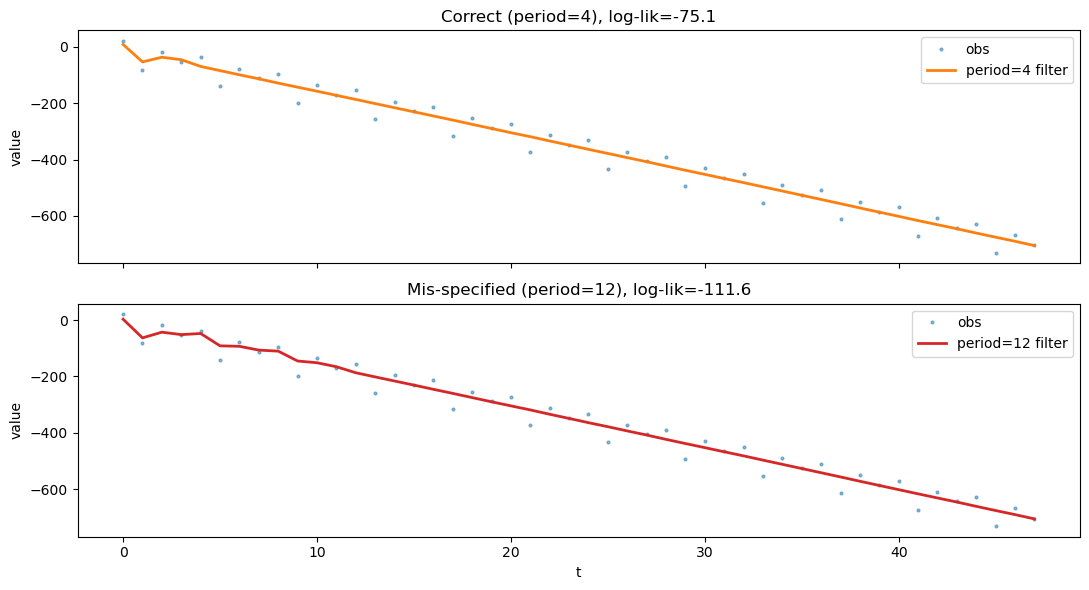

In [7]:
# Exercise 2 — Fit monthly (period=12) to quarterly seasonal data; compare log-likelihoods

# Generate quarterly seasonal series
llt_q  = make_local_linear_trend(V=0.25, W_level=0.05, W_slope=0.001)
seas_q = make_seasonal_factor(period=4, V=0.25, W_season=0.01)
spec_q = combine(llt_q, seas_q)
sim_q  = simulate(spec_q, n=48, seed=99)

# Correct model: period=4
llt_4   = make_local_linear_trend(V=0.25, W_level=0.05, W_slope=0.001)
seas_4  = make_seasonal_factor(period=4, V=0.25, W_season=0.01)
spec_4  = combine(llt_4, seas_4)
fr_4    = kalman_filter(spec_4, sim_q.y)

# Mis-specified model: period=12 (needs at least 12 steps of state, only 48 obs)
llt_12  = make_local_linear_trend(V=0.25, W_level=0.05, W_slope=0.001)
seas_12 = make_seasonal_factor(period=12, V=0.25, W_season=0.01)
spec_12 = combine(llt_12, seas_12)
fr_12   = kalman_filter(spec_12, sim_q.y)

print(f'Correct model (period=4)  log-lik: {fr_4.loglik:.2f}')
print(f'Mis-specified (period=12) log-lik: {fr_12.loglik:.2f}')
print(f'Advantage of correct model: {fr_4.loglik - fr_12.loglik:.2f} log-units')
print('Correct period=4 model wins — mis-specification hurts the likelihood')

t_q = np.arange(48)
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(t_q, sim_q.y[:, 0], '.', ms=4, alpha=0.5, label='obs')
axes[0].plot(t_q, fr_4.m[:, 0], 'C1-', lw=2, label='period=4 filter')
axes[0].set_ylabel('value'); axes[0].legend()
axes[0].set_title(f'Correct (period=4), log-lik={fr_4.loglik:.1f}')

axes[1].plot(t_q, sim_q.y[:, 0], '.', ms=4, alpha=0.5, label='obs')
axes[1].plot(t_q, fr_12.m[:, 0], 'C3-', lw=2, label='period=12 filter')
axes[1].set_xlabel('t'); axes[1].set_ylabel('value'); axes[1].legend()
axes[1].set_title(f'Mis-specified (period=12), log-lik={fr_12.loglik:.1f}')

plt.tight_layout()
plt.show()
